<a href="https://colab.research.google.com/github/dyermelissa625-jpg/break_the_ice/blob/main/EE_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, linregress

In [ ]:
df = pd.read_csv("ShipwreckData.csv")


In [ ]:
# Reducing dataset
analysis = df[
    [
        "ID",
        "Shipwreck",
        "DO_mgL",
        "Conductivity_mScm",
        "Corrosion_Rate_mmyr"
    ]
].copy()

analysis

,ID,Shipwreck,DO_mgL,Conductivity_mScm,Corrosion_Rate_mmyr
0,1,USS Arizona,4.76,54.83,0.0690
1,2,USS Arizona,2.45,53.97,0.0330
2,3,Fujikawa Maru,6.20,54.55,0.0950
3,4,Fujikawa Maru – bow gun,6.50,54.55,0.1990
4,5,Yubae Maru,5.10,52.44,0.0950
5,6,Sub Marine Explorer,6.90,50.97,0.0510
6,7,Hoyo Maru,6.70,53.87,0.1355
7,8,WWII Wreck – Chuuk open ocean (shallow),7.00,55.34,0.1260
8,9,USS Missouri (museum ship),4.98,54.48,0.0460
9,10,Tanker Prestige,7.71,32.08,0.0570


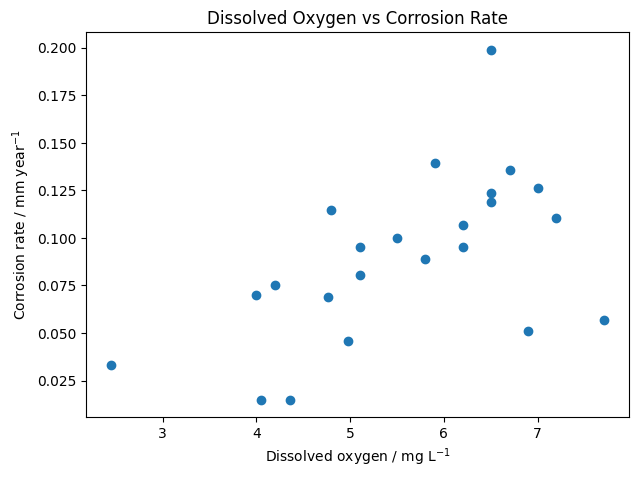

In [ ]:
# Scatter plot of Dissolved oxygen against corrosion rate
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.scatter(
    analysis["DO_mgL"],
    analysis["Corrosion_Rate_mmyr"]
)

plt.xlabel("Dissolved oxygen / mg L$^{-1}$")
plt.ylabel("Corrosion rate / mm year$^{-1}$")
plt.title("Dissolved Oxygen vs Corrosion Rate")

plt.show()

In [ ]:
# Calculating strength of the relationship between DO and corrosion rate
from scipy.stats import pearsonr

r_do, p_do = pearsonr(
    analysis["DO_mgL"],
    analysis["Corrosion_Rate_mmyr"]
)
r2_do = r_do**2

print("Pearson r =", r_do)
print("p-value =", p_do)
print("R² =", r2_do)
print("Percentage of variance explained =", r2_do * 100)

Pearson r = 0.5452008848887686
p-value = 0.007135258505303475
R² = 0.29724400488349634
Percentage of variance explained = 29.724400488349634


In [ ]:
#Performing linear regression on DO and corrosion rate
from scipy.stats import linregress
import numpy as np

x = analysis["DO_mgL"].to_numpy()
y = analysis["Corrosion_Rate_mmyr"].to_numpy()

reg_do = linregress(x, y)

predicted = reg_do.slope * x + reg_do.intercept
residuals = y - predicted

print("Slope =", reg_do.slope)
print("Intercept =", reg_do.intercept)

Slope = 0.018531791759960902
Intercept = -0.013702929560720847


In [ ]:
#Calculating residuals for the DO vs Corrosion model

diagnostics = analysis.copy()

diagnostics["Predicted_CR"] = predicted
diagnostics["Residual"] = residuals
diagnostics["Absolute_Residual"] = np.abs(residuals)

diagnostics.sort_values(
    "Absolute_Residual",
    ascending=False
)[
    [
        "ID",
        "Shipwreck",
        "DO_mgL",
        "Corrosion_Rate_mmyr",
        "Predicted_CR",
        "Residual",
        "Absolute_Residual"
    ]
]

,ID,Shipwreck,DO_mgL,Corrosion_Rate_mmyr,Predicted_CR,Residual,Absolute_Residual
3,4,Fujikawa Maru – bow gun,6.50,0.1990,0.106754,0.092246,0.092246
9,10,Tanker Prestige,7.71,0.0570,0.129177,-0.072177,0.072177
5,6,Sub Marine Explorer,6.90,0.0510,0.114166,-0.063166,0.063166
11,12,Japanese Midget Submarine (JMS),4.36,0.0150,0.067096,-0.052096,0.052096
12,13,Japanese Midget Submarine #5 (JMS #5),4.05,0.0150,0.061351,-0.046351,0.046351
17,18,Susuki patrol boat,5.90,0.1394,0.095635,0.043765,0.043765
16,17,Shinkoku Maru,4.80,0.1149,0.075250,0.039650,0.039650
8,9,USS Missouri (museum ship),4.98,0.0460,0.078585,-0.032585,0.032585
6,7,Hoyo Maru,6.70,0.1355,0.110460,0.025040,0.025040
13,14,Fujikawa Maru – windlass,6.50,0.1235,0.106754,0.016746,0.016746


In [ ]:
# Exclude only the Fujikawa Maru – bow gun (ID 4) to test it as a potentntial outlier
without_bow_gun = analysis[analysis["ID"] != 4]

r_no_bow, p_no_bow = pearsonr(
    without_bow_gun["DO_mgL"],
    without_bow_gun["Corrosion_Rate_mmyr"]
)

r2_no_bow = r_no_bow**2

print("Without Fujikawa Maru – bow gun:")
print("n =", len(without_bow_gun))
print("Pearson r =", r_no_bow)
print("R² =", r2_no_bow)
print("Percentage of variance explained =", r2_no_bow * 100)
print("p-value =", p_no_bow)

Without Fujikawa Maru – bow gun:
n = 22
Pearson r = 0.5563090256394183
R² = 0.309479732007879
Percentage of variance explained = 30.9479732007879
p-value = 0.007173080550186161


In [ ]:
analysis_climate = df[[
    "ID",
    "Shipwreck",
    "Climate",
    "DO_mgL",
    "Corrosion_Rate_mmyr"
]].copy()

analysis_climate.groupby("Climate").size()


,0
Climate,
Subtropical/Tropical,5
Temperate,1
Tropical,17


In [ ]:
analysis_climate[["Climate", "Shipwreck"]].sort_values("Climate")

,Climate,Shipwreck
0,Subtropical/Tropical,USS Arizona
12,Subtropical/Tropical,Japanese Midget Submarine #5 (JMS #5)
8,Subtropical/Tropical,USS Missouri (museum ship)
11,Subtropical/Tropical,Japanese Midget Submarine (JMS)
1,Subtropical/Tropical,USS Arizona
9,Temperate,Tanker Prestige
4,Tropical,Yubae Maru
20,Tropical,Nippo Maru
19,Tropical,Yamamoto gun boat
18,Tropical,Tonoas Dock Boat


In [ ]:
tropical = analysis_climate[
    analysis_climate["Climate"] == "Tropical"
].copy()

r_tropical, p_tropical = pearsonr(
    tropical["DO_mgL"],
    tropical["Corrosion_Rate_mmyr"]
)

r2_tropical = r_tropical**2

print("Tropical observations:")
print("n =", len(tropical))
print("Pearson r =", r_tropical)
print("R² =", r2_tropical)
print("Percentage of variance explained =", r2_tropical * 100)
print("p-value =", p_tropical)

Tropical observations:
n = 17
Pearson r = 0.4086137193631852
R² = 0.16696517165181587
Percentage of variance explained = 16.696517165181586
p-value = 0.10343178075873741


/tmp/ipykernel_2412/2563581669.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


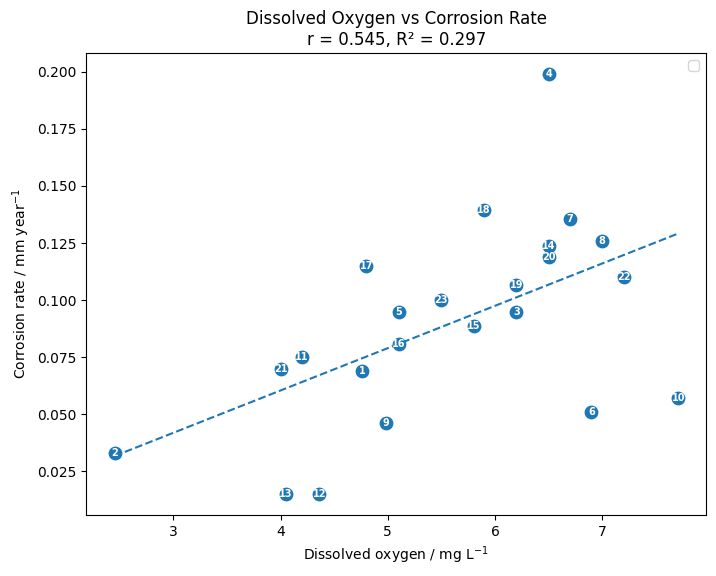

In [ ]:
#DO vs corrosion graph with line of regression

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 6))

plt.scatter(
    analysis["DO_mgL"],
    analysis["Corrosion_Rate_mmyr"],
    s=80
)

for idx in analysis.index:
    plt.annotate(
        str(analysis.loc[idx, "ID"]),
        (
            analysis.loc[idx, "DO_mgL"],
            analysis.loc[idx, "Corrosion_Rate_mmyr"]
        ),
        ha="center",
        va="center",
        fontsize=7,
        fontweight="bold",
        color="white"
    )

x_line = np.linspace(
    analysis["DO_mgL"].min(),
    analysis["DO_mgL"].max(),
    100
)

y_line = reg_do.slope * x_line + reg_do.intercept

plt.plot(x_line,y_line,linestyle="--")

plt.xlabel("Dissolved oxygen / mg L$^{-1}$")
plt.ylabel("Corrosion rate / mm year$^{-1}$")

plt.title(
    f"Dissolved Oxygen vs Corrosion Rate\n"
    f"r = {r_do:.3f}, R² = {r2_do:.3f}"
)

plt.legend()

plt.show()

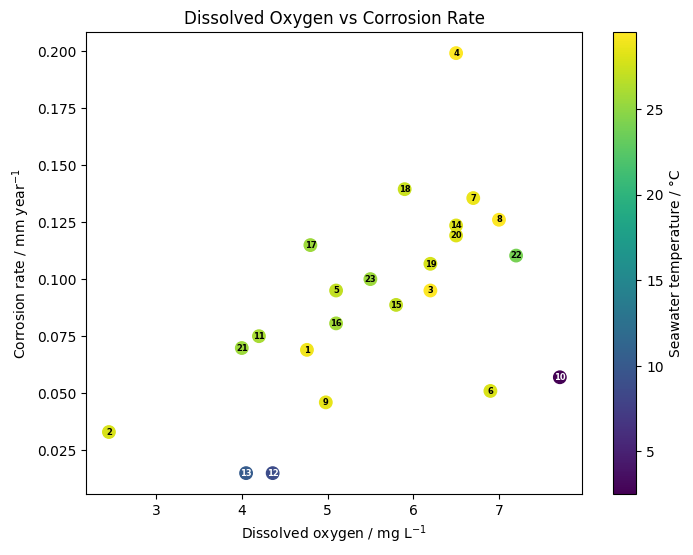

In [ ]:
#DO vs corrosion rate with temperature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.figure(figsize=(8, 6))

temperatures = df.loc[analysis.index, "Temperature_C"]

scatter = plt.scatter(
    analysis["DO_mgL"],
    analysis["Corrosion_Rate_mmyr"],
    c=temperatures,
    cmap="viridis",
    s=80
)

norm = plt.Normalize(temperatures.min(), temperatures.max())
cmap = plt.cm.viridis

for idx in analysis.index:

    temperature = temperatures.loc[idx]
    rgba = cmap(norm(temperature))

    brightness = (
        0.299 * rgba[0]
        + 0.587 * rgba[1]
        + 0.114 * rgba[2]
    )

    text_color = "white" if brightness < 0.5 else "black"

    plt.annotate(
        str(df.loc[idx, "ID"]),
        (
            df.loc[idx, "DO_mgL"],
            df.loc[idx, "Corrosion_Rate_mmyr"]
        ),
        ha="center",
        va="center",
        fontsize=6,
        fontweight="bold",
        color=text_color
    )


plt.colorbar(scatter, label="Seawater temperature / °C")

plt.xlabel("Dissolved oxygen / mg L$^{-1}$")
plt.ylabel("Corrosion rate / mm year$^{-1}$")
plt.title("Dissolved Oxygen vs Corrosion Rate")

plt.show()

In [ ]:
#Linear regression on Conductivity vs Corrosion

x = analysis["Conductivity_mScm"].to_numpy()
y = analysis["Corrosion_Rate_mmyr"].to_numpy()

r_cond, p_cond = pearsonr(x, y)

reg_cond = linregress(x, y)

print("Pearson r =", r_cond)
print("p-value =", p_cond)
print("Slope =", reg_cond.slope)
print("Intercept =", reg_cond.intercept)
print("R² =", reg_cond.rvalue**2)

Pearson r = 0.547290226623504
p-value = 0.006874734243605794
Slope = 0.0038694251567756447
Intercept = -0.10641898588330777
R² = 0.2995265921576064


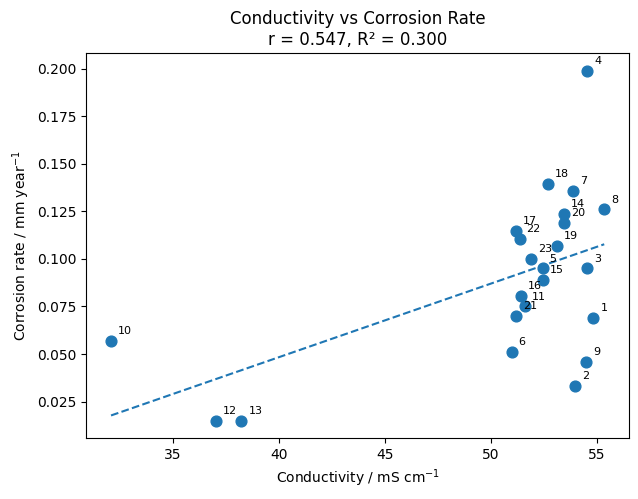

In [ ]:
#Conductivity vs corrosion rate plot

x_line = np.linspace(x.min(), x.max(), 100)
y_line = reg_cond.slope * x_line + reg_cond.intercept

plt.figure(figsize=(7, 5))

plt.scatter(x, y, s=60)

for idx in analysis.index:
    plt.annotate(
        str(df.loc[idx, "ID"]),
        (
            df.loc[idx, "Conductivity_mScm"],
            df.loc[idx, "Corrosion_Rate_mmyr"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.plot(x_line, y_line, linestyle="--")

plt.xlabel("Conductivity / mS cm$^{-1}$")
plt.ylabel("Corrosion rate / mm year$^{-1}$")

plt.title(
    f"Conductivity vs Corrosion Rate\n"
    f"r = {r_cond:.3f}, R² = {reg_cond.rvalue**2:.3f}"
)

plt.show()


In [ ]:
#Calculating Residuals for Conductivity vs Corrosion
predicted_cond = reg_cond.slope * x + reg_cond.intercept

residuals_cond = y - predicted_cond

diagnostics_cond = analysis.copy()

diagnostics_cond["Predicted_CR"] = predicted_cond
diagnostics_cond["Residual"] = residuals_cond
diagnostics_cond["Absolute_Residual"] = np.abs(residuals_cond)

diagnostics_cond.sort_values(
    "Absolute_Residual",
    ascending=False
)[
    [
        "ID",
        "Shipwreck",
        "Conductivity_mScm",
        "Corrosion_Rate_mmyr",
        "Predicted_CR",
        "Residual",
        "Absolute_Residual"
    ]
]

,ID,Shipwreck,Conductivity_mScm,Corrosion_Rate_mmyr,Predicted_CR,Residual,Absolute_Residual
3,4,Fujikawa Maru – bow gun,54.55,0.1990,0.104658,0.094342,0.094342
1,2,USS Arizona,53.97,0.0330,0.102414,-0.069414,0.069414
8,9,USS Missouri (museum ship),54.48,0.0460,0.104387,-0.058387,0.058387
17,18,Susuki patrol boat,52.69,0.1394,0.097461,0.041939,0.041939
5,6,Sub Marine Explorer,50.97,0.0510,0.090806,-0.039806,0.039806
9,10,Tanker Prestige,32.08,0.0570,0.017712,0.039288,0.039288
0,1,USS Arizona,54.83,0.0690,0.105742,-0.036742,0.036742
6,7,Hoyo Maru,53.87,0.1355,0.102027,0.033473,0.033473
12,13,Japanese Midget Submarine #5 (JMS #5),38.23,0.0150,0.041509,-0.026509,0.026509
16,17,Shinkoku Maru,51.17,0.1149,0.091579,0.023321,0.023321


In [ ]:
# Exclude only the Fujikawa Maru – bow gun (ID 4)
# to test its influence on the conductivity relationship

without_bow_gun = analysis[analysis["ID"] != 4]

r_no_bow_cond, p_no_bow_cond = pearsonr(
    without_bow_gun["Conductivity_mScm"],
    without_bow_gun["Corrosion_Rate_mmyr"]
)

r2_no_bow_cond = r_no_bow_cond**2

print("Without Fujikawa Maru – bow gun:")
print("n =", len(without_bow_gun))
print("Pearson r =", r_no_bow_cond)
print("R² =", r2_no_bow_cond)
print("Percentage of variance explained =", r2_no_bow_cond * 100)
print("p-value =", p_no_bow_cond)

Without Fujikawa Maru – bow gun:
n = 22
Pearson r = 0.5703599940080125
R² = 0.3253105227648201
Percentage of variance explained = 32.53105227648201
p-value = 0.005576657460417081


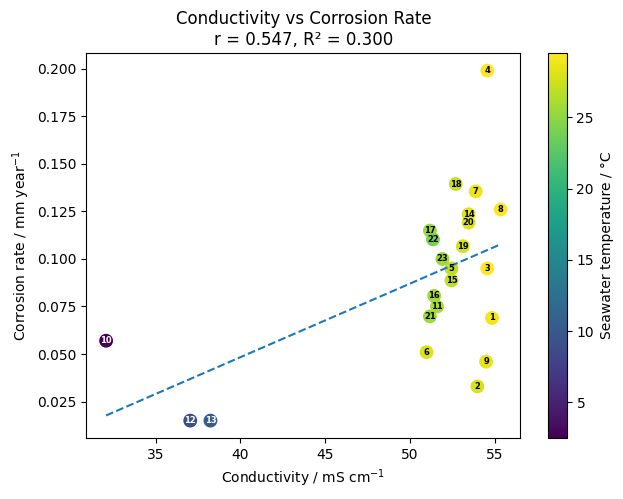

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

# Temperature values
temperatures = df.loc[analysis.index, "Temperature_C"]

# Scatter plot coloured by temperature
scatter = plt.scatter(
    x,
    y,
    c=temperatures,
    cmap="viridis",
    s=80
)

norm = plt.Normalize(temperatures.min(), temperatures.max())
cmap = plt.cm.viridis

# Add ID numbers inside each marker
for idx in analysis.index:

    temperature = temperatures.loc[idx]
    rgba = cmap(norm(temperature))

    brightness = (
        0.299 * rgba[0]
        + 0.587 * rgba[1]
        + 0.114 * rgba[2]
    )

    text_color = "white" if brightness < 0.5 else "black"

    plt.annotate(
        str(df.loc[idx, "ID"]),
        (
            df.loc[idx, "Conductivity_mScm"],
            df.loc[idx, "Corrosion_Rate_mmyr"]
        ),
        ha="center",
        va="center",
        fontsize=6,
        fontweight="bold",
        color=text_color
    )

# Regression line
x_line = np.linspace(x.min(), x.max(), 100)
y_line = reg_cond.slope * x_line + reg_cond.intercept

plt.plot(
    x_line,
    y_line,
    linestyle="--"
)

# Temperature colourbar
plt.colorbar(
    scatter,
    label="Seawater temperature / °C"
)

plt.xlabel("Conductivity / mS cm$^{-1}$")
plt.ylabel("Corrosion rate / mm year$^{-1}$")

plt.title(
    f"Conductivity vs Corrosion Rate\n"
    f"r = {r_cond:.3f}, R² = {reg_cond.rvalue**2:.3f}"
)

plt.show()

In [ ]:
import statsmodels.api as sm

X = analysis[["DO_mgL", "Conductivity_mScm"]]
y = analysis["Corrosion_Rate_mmyr"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     Corrosion_Rate_mmyr   R-squared:                       0.591
Model:                             OLS   Adj. R-squared:                  0.550
Method:                  Least Squares   F-statistic:                     14.46
Date:                 Tue, 25 Aug 2026   Prob (F-statistic):           0.000130
Time:                         06:01:26   Log-Likelihood:                 50.351
No. Observations:                   23   AIC:                            -94.70
Df Residuals:                       20   BIC:                            -91.30
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.2071

In [ ]:
predictor_corr = analysis[[
    "DO_mgL",
    "Conductivity_mScm"
]].corr()

predictor_corr

,DO_mgL,Conductivity_mScm
DO_mgL,1.000000,0.009481
Conductivity_mScm,0.009481,1.000000


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = analysis[["DO_mgL", "Conductivity_mScm"]]
X_vif = sm.add_constant(X_vif)

vif = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif

,Variable,VIF
0,const,91.846584
1,DO_mgL,1.000090
2,Conductivity_mScm,1.000090


In [ ]:
# Experimental measurements for the three shipwrecks

wreck_data = pd.DataFrame({
    "Shipwreck": [
        "Mogami Maru",
        "MV Alma Jane",
        "MV Geopeter"
    ],
    "DO_mgL": [
        6.4,
        5.6,
        7.2
    ],
    "Conductivity_mScm": [
        61.215,
        62.265,
        51.710
    ]
})

# Combined regression coefficients from the secondary dataset
intercept = -0.1139
do_coef = 0.0158
cond_coef = 0.0024

wreck_data["Predicted_CR_combined"] = (
    intercept
    + do_coef * wreck_data["DO_mgL"]
    + cond_coef * wreck_data["Conductivity_mScm"]
)

wreck_data

,Shipwreck,DO_mgL,Conductivity_mScm,Predicted_CR_combined
0,Mogami Maru,6.4,61.215,0.134136
1,MV Alma Jane,5.6,62.265,0.124016
2,MV Geopeter,7.2,51.710,0.123964


In [ ]:
# DO-only regression
do_model = linregress(
    analysis["DO_mgL"],
    analysis["Corrosion_Rate_mmyr"]
)

# Conductivity-only regression
cond_model = linregress(
    analysis["Conductivity_mScm"],
    analysis["Corrosion_Rate_mmyr"]
)

wreck_data["Predicted_CR_DO_only"] = (
    do_model.intercept
    + do_model.slope * wreck_data["DO_mgL"]
)

wreck_data["Predicted_CR_Conductivity_only"] = (
    cond_model.intercept
    + cond_model.slope * wreck_data["Conductivity_mScm"]
)

wreck_data

,Shipwreck,DO_mgL,Conductivity_mScm,Predicted_CR_combined,Predicted_CR_DO_only,Predicted_CR_Conductivity_only
0,Mogami Maru,6.4,61.215,0.134136,0.104901,0.130448
1,MV Alma Jane,5.6,62.265,0.124016,0.090075,0.134511
2,MV Geopeter,7.2,51.710,0.123964,0.119726,0.093669
